In [1]:
import pandas as pd
import numpy as np
import nltk
from transformers import pipeline
import sklearn
import statsmodels.api as sm

# Importing Dataset

In [2]:
# Load dataset
import pandas as pd

df = pd.read_excel("Airline_Reviews_Asia (2021-2025).xlsx")

# Preview data
df.head()

,Airline,Title,Author,Country,Date,Verified,Review,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended,Aircraft
0,Air Arabia,"""Pathetic service""",Rabiya Saeed,Qatar,20th April 2025,False,Not Verified| This was the biggest rip off in...,Solo Leisure,Economy Class,Doha to Lahore via Sharjah,April 2025,1.0,3.0,1.0,1.0,2.0,1.0,1,no,NaN
1,Air Arabia,"""first and last flight with Air Arabia""",Marek Koval,Slovakia,8th April 2025,False,Not Verified| Disappointed with Air Arabia – p...,Couple Leisure,Economy Class,Sharjah to Vienna,March 2025,1.0,1.0,1.0,1.0,1.0,2.0,1,no,NaN
2,Air Arabia,"""still waiting for delay compensation""",Amira Hashi,United Kingdom,5th March 2025,True,"✅Trip Verified| Terrible service, still wait...",Solo Leisure,Economy Class,Gatwick to Tangier,August 2024,1.0,3.0,2.0,NaN,1.0,NaN,1,no,NaN
3,Air Arabia,“highly restrictive and unfair policy”,Pradip Dhakal,United Arab Emirates,1st March 2025,False,Not Verified| I recently had a very disappoint...,Solo Leisure,Economy Class,Kathmandu to Abu Dhabi,January 2025,2.0,2.0,3.0,1.0,1.0,2.0,1,no,NaN
4,Air Arabia,"""Better off avoiding this airline""",G Zamaris,Greece,13th February 2025,True,✅Trip Verified| Terrible experience with this ...,Couple Leisure,Economy Class,Athens to Bangkok,January 2025,1.0,1.0,1.0,1.0,1.0,1.0,1,no,A321


## Drop unnecessary columns

In [3]:
df = df[['Airline','Review',
         'Seat Comfort',
         'Cabin Staff Service',
         'Food & Beverages',
         'Inflight Entertainment',
         'Ground Service',
         'Wifi & Connectivity',
         'Value For Money',
         'Recommended']]
df = df.copy()

In [4]:
df.head()

,Airline,Review,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended
0,Air Arabia,Not Verified| This was the biggest rip off in...,1.0,3.0,1.0,1.0,2.0,1.0,1,no
1,Air Arabia,Not Verified| Disappointed with Air Arabia – p...,1.0,1.0,1.0,1.0,1.0,2.0,1,no
2,Air Arabia,"✅Trip Verified| Terrible service, still wait...",1.0,3.0,2.0,NaN,1.0,NaN,1,no
3,Air Arabia,Not Verified| I recently had a very disappoint...,2.0,2.0,3.0,1.0,1.0,2.0,1,no
4,Air Arabia,✅Trip Verified| Terrible experience with this ...,1.0,1.0,1.0,1.0,1.0,1.0,1,no


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Airline                 1728 non-null   object 
 1   Review                  1728 non-null   object 
 2   Seat Comfort            1562 non-null   float64
 3   Cabin Staff Service     1541 non-null   float64
 4   Food & Beverages        1186 non-null   float64
 5   Inflight Entertainment  893 non-null    float64
 6   Ground Service          1640 non-null   float64
 7   Wifi & Connectivity     639 non-null    float64
 8   Value For Money         1728 non-null   int64  
 9   Recommended             1728 non-null   object 
dtypes: float64(6), int64(1), object(3)
memory usage: 135.1+ KB


In [6]:
# Check missing values again
df.isnull().sum()

Airline                      0
Review                       0
Seat Comfort               166
Cabin Staff Service        187
Food & Beverages           542
Inflight Entertainment     835
Ground Service              88
Wifi & Connectivity       1089
Value For Money              0
Recommended                  0
dtype: int64

## Data Preprocessing

In [7]:
rating_cols = ['Seat Comfort',
               'Cabin Staff Service',
               'Food & Beverages',
               'Inflight Entertainment',
               'Ground Service',
               'Wifi & Connectivity',
               'Value For Money']

df[rating_cols] = df[rating_cols].fillna(0)

In [8]:
df.isnull().sum()

Airline                   0
Review                    0
Seat Comfort              0
Cabin Staff Service       0
Food & Beverages          0
Inflight Entertainment    0
Ground Service            0
Wifi & Connectivity       0
Value For Money           0
Recommended               0
dtype: int64

In [9]:
df['Recommended'] = df['Recommended'].str.lower().map({'yes': 1, 'no': 0})

## Text Cleaning

In [10]:
import re

def clean_text(text):
    text = str(text).lower()
    
    # Remove symbols
    text = re.sub(r'[^\x00-\x7F]+', '', text)   # removes emojis/symbols
    text = re.sub(r'\|', ' ', text)             # replace | with space
    
    # Remove metadata
    text = re.sub(r'trip verified', '', text)
    text = re.sub(r'verified review', '', text)
    text = re.sub(r'not verified', '', text)
    
    # Remove punctuation and numbers
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    text = re.sub(r'\s+', ' ', text)  # remove extra spaces inside
    return text.strip()

df['clean_review'] = df['Review'].apply(clean_text)

In [11]:
df[['Review', 'clean_review']].head()

,Review,clean_review
0,Not Verified| This was the biggest rip off in...,this was the biggest rip off in my experience ...
1,Not Verified| Disappointed with Air Arabia – p...,disappointed with air arabia poor service i fl...
2,"✅Trip Verified| Terrible service, still wait...",terrible service still waiting for delay compe...
3,Not Verified| I recently had a very disappoint...,i recently had a very disappointing experience...
4,✅Trip Verified| Terrible experience with this ...,terrible experience with this airline the airp...


# NLP Preprocessing (Tokenization, Stopwords, Lemmatization)

In [13]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [14]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sanosh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sanosh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sanosh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sanosh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [15]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [16]:
def preprocess_text(text):
    tokens = word_tokenize(text)
    
    cleaned_tokens = []
    for word in tokens:
        if word not in stop_words:
            word = lemmatizer.lemmatize(word)
            cleaned_tokens.append(word)
    
    return " ".join(cleaned_tokens)

In [17]:
df['processed_review'] = df['clean_review'].apply(preprocess_text)

In [18]:
df[['clean_review', 'processed_review']].head()

,clean_review,processed_review
0,this was the biggest rip off in my experience ...,biggest rip experience offered relatively lowe...
1,disappointed with air arabia poor service i fl...,disappointed air arabia poor service flew air ...
2,terrible service still waiting for delay compe...,terrible service still waiting delay compensat...
3,i recently had a very disappointing experience...,recently disappointing experience air arabia r...
4,terrible experience with this airline the airp...,terrible experience airline airplane badly mai...


# Lexicon-Based Sentiment Analysis (VADER)

In [19]:
from nltk.sentiment import SentimentIntensityAnalyzer

In [20]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\sanosh\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [21]:
sia = SentimentIntensityAnalyzer()

## Sentiment Score

In [22]:
df['sentiment_score'] = df['processed_review'].apply(lambda x: sia.polarity_scores(x)['compound'])

In [23]:
df[['processed_review', 'sentiment_score']].head()

,processed_review,sentiment_score
0,biggest rip experience offered relatively lowe...,-0.0917
1,disappointed air arabia poor service flew air ...,-0.7401
2,terrible service still waiting delay compensat...,-0.8555
3,recently disappointing experience air arabia r...,0.3257
4,terrible experience airline airplane badly mai...,-0.7579


## Converting Sentiment Scores into Sentiment Labels

In [24]:
def get_sentiment_label(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['vader_sentiment'] = df['sentiment_score'].apply(get_sentiment_label)

In [25]:
df[['sentiment_score', 'vader_sentiment']].head()

,sentiment_score,vader_sentiment
0,-0.0917,Negative
1,-0.7401,Negative
2,-0.8555,Negative
3,0.3257,Positive
4,-0.7579,Negative


## Check Sentiment Distribution

In [26]:
df['vader_sentiment'].value_counts()

vader_sentiment
Positive    908
Negative    805
Neutral      15
Name: count, dtype: int64

## Visualization of Sentiment Distribution (VADER)

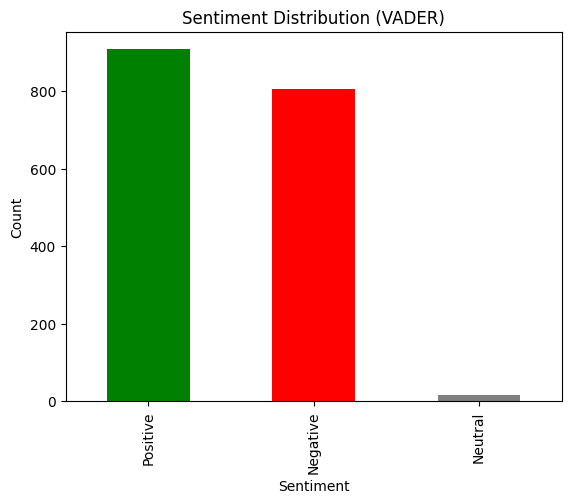

In [27]:
import matplotlib.pyplot as plt

df['vader_sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'grey'])
plt.title("Sentiment Distribution (VADER)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

- The sentiment distribution shows that positive reviews (908) outnumber negative reviews (805), indicating a generally favorable customer perception.

- However, the relatively high number of negative reviews suggests the presence of notable service issues.

- Neutral reviews are minimal (15), indicating that passengers tend to express clear satisfaction or dissatisfaction rather than neutral opinions.

# Transformer-Based Sentiment Analysis (BERT)

- BERT (Bidirectional Encoder Representations from Transformers) is a transformer-based NLP model.

- It understands context by reading text in both directions (left + right).

- Uses an attention mechanism to focus on important words in a sentence.

- Captures semantic meaning, not just individual word polarity. Provides more accurate sentiment analysis than lexicon-based methods.

- Pre-trained on large datasets = strong language understanding.

In [28]:
from transformers import pipeline

## Load BERT Sentiment Model

In [29]:
bert_model = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

### Test the Model

In [30]:
bert_model("The flight was excellent and the staff were very helpful")

[{'label': 'POSITIVE', 'score': 0.9998524188995361}]

## Applying BERT to the Dataset

In [31]:
df['bert_result'] = df['processed_review'].apply(
    lambda x: bert_model(x, truncation=True)[0]
)

- To handle input length limitations of the BERT model, long reviews were truncated to fit within the maximum token limit.

In [32]:
df['bert_sentiment'] = df['bert_result'].apply(lambda x: x['label'])

In [33]:
df[['processed_review', 'bert_sentiment']].head()

,processed_review,bert_sentiment
0,biggest rip experience offered relatively lowe...,NEGATIVE
1,disappointed air arabia poor service flew air ...,NEGATIVE
2,terrible service still waiting delay compensat...,NEGATIVE
3,recently disappointing experience air arabia r...,NEGATIVE
4,terrible experience airline airplane badly mai...,NEGATIVE


## BERT Sentiment Distribution

In [36]:
df['bert_sentiment'].value_counts()

bert_sentiment
NEGATIVE    1352
POSITIVE     376
Name: count, dtype: int64

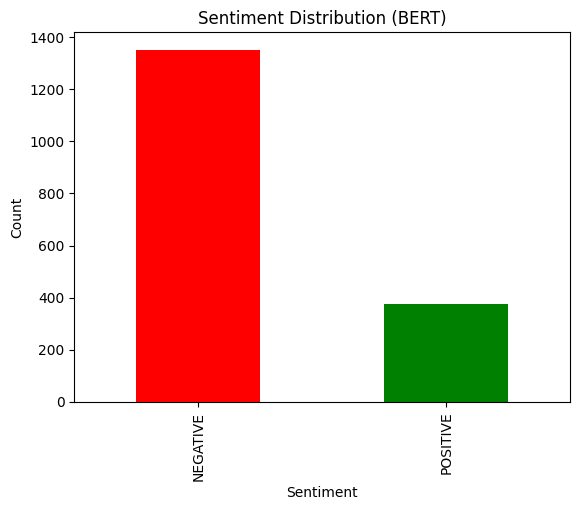

In [37]:
import matplotlib.pyplot as plt

df['bert_sentiment'].value_counts().plot(kind='bar', color=['red', 'green'])

plt.title("Sentiment Distribution (BERT)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

- The BERT model classified a majority of reviews as negative (1352) compared to positive (376), indicating a strong skew toward negative sentiment.

- This differs significantly from the lexicon-based results, where positive sentiment dominated.

- The discrepancy can be attributed to the model’s contextual understanding and lack of a neutral category, which forces classification into binary outcomes.

- Additionally, the pre-trained model may not be fully optimized for the airline domain, leading to stricter sentiment interpretation.

## Comparison of Sentiment Classification: VADER vs BERT

In [38]:
pd.crosstab(df['vader_sentiment'], df['bert_sentiment'])

bert_sentiment,NEGATIVE,POSITIVE
vader_sentiment,,
Negative,801,4
Neutral,15,0
Positive,536,372


- A high level of agreement is observed for negative reviews, with both models classifying 801 reviews as negative.

- However, significant divergence exists for positive reviews, where 536 reviews classified as positive by VADER are labeled as negative by BERT.

- All neutral reviews (15) identified by VADER are classified as negative by BERT due to the absence of a neutral category.

- The results indicate that the transformer-based model applies stricter sentiment classification, leading to a higher proportion of negative sentiment.

# Aspect-Level Analysis: Average Service Ratings by Sentiment

- The VADER model was used for aspect-level analysis due to its ability to classify sentiment into positive, negative, and neutral categories.

- This aligns well with the ordinal nature of service ratings, allowing for more meaningful grouping and comparison.

- In contrast, the transformer-based model provides binary classification, which may lead to skewed grouping and less reliable aspect-level insights.

- The analysis excludes imputed zero values to ensure that only valid service ratings are considered, resulting in more accurate representation of customer evaluations.
- Wifi and connectivity aspect is excluded due to high missing values and inconsistent availability across flights.

In [39]:
df.groupby('vader_sentiment')[['Seat Comfort',
                         'Cabin Staff Service',
                         'Food & Beverages',
                         'Inflight Entertainment',
                         'Ground Service',
                         'Value For Money']].apply(lambda x: x[x != 0].mean())

,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Value For Money
vader_sentiment,,,,,,
Negative,1.815789,1.936937,1.594360,1.483607,1.470190,1.453416
Neutral,1.714286,1.571429,1.363636,1.500000,1.214286,1.200000
Positive,3.483796,3.849013,3.487395,3.100580,3.528153,3.441630


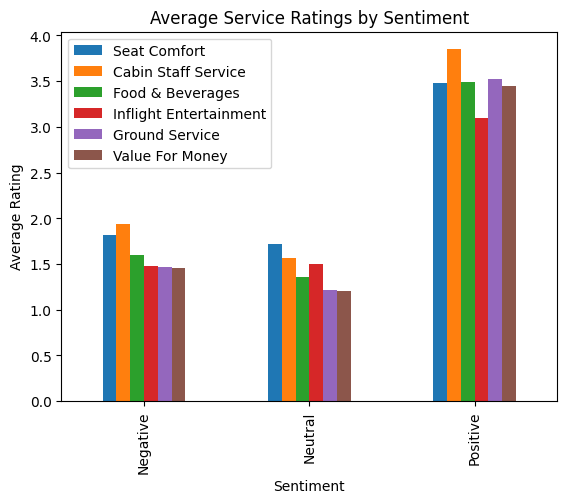

In [40]:
df_corrected = df.groupby('vader_sentiment')[['Seat Comfort',
                                        'Cabin Staff Service',
                                        'Food & Beverages',
                                        'Inflight Entertainment',
                                        'Ground Service',
                                        'Value For Money']].apply(lambda x: x[x != 0].mean())

df_corrected.plot(kind='bar')

plt.title("Average Service Ratings by Sentiment")
plt.ylabel("Average Rating")
plt.xlabel("Sentiment")
plt.show()

- The aspect-level analysis shows a clear relationship between sentiment and service ratings, where higher ratings are associated with positive sentiment and lower ratings with negative sentiment.
  
- Positive reviews are associated with higher ratings across all service dimensions, particularly cabin staff service (3.85), indicating strong performance in staff interaction.

- Negative reviews correspond with significantly lower ratings, especially in inflight entertainment (1.48) and food & beverages (1.59), highlighting weaker performance in onboard amenities.

- These findings indicate that service quality strongly influences customer sentiment, with staff service as a key strength and inflight entertainment and food services as primary areas of dissatisfaction.

# Correlation Between Sentiment Score and Recommendation

In [41]:
df[['sentiment_score', 'Recommended']].corr()

,sentiment_score,Recommended
sentiment_score,1.000000,0.700634
Recommended,0.700634,1.000000


- The correlation between sentiment score and customer recommendation behaviour is 0.70, indicating a strong positive relationship.

- This suggests that as sentiment becomes more positive, the likelihood of recommending the airline also increases.

- The strength of the correlation (0.7006) highlights that customer sentiment is a significant indicator of recommendation behaviour.

- These findings imply that passenger perceptions expressed in reviews play an important role in influencing their decision to recommend an airline.

## Correlation Matrix (Ratings vs Recommendation)

In [42]:
df_corr = df.copy()

rating_cols = ['Seat Comfort',
               'Cabin Staff Service',
               'Food & Beverages',
               'Inflight Entertainment',
               'Ground Service',
               'Value For Money']

# Replace 0 with NaN (so pandas ignores them in correlation)
import numpy as np
df_corr[rating_cols] = df_corr[rating_cols].replace(0, np.nan)

# Correlation
df_corr[rating_cols + ['Recommended']].corr()

,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Value For Money,Recommended
Seat Comfort,1.000000,0.771650,0.730938,0.728883,0.763966,0.810183,0.706110
Cabin Staff Service,0.771650,1.000000,0.799065,0.671333,0.720014,0.781306,0.739672
Food & Beverages,0.730938,0.799065,1.000000,0.766346,0.681684,0.758220,0.747378
Inflight Entertainment,0.728883,0.671333,0.766346,1.000000,0.669458,0.693920,0.663881
Ground Service,0.763966,0.720014,0.681684,0.669458,1.000000,0.836788,0.775483
Value For Money,0.810183,0.781306,0.758220,0.693920,0.836788,1.000000,0.823813
Recommended,0.706110,0.739672,0.747378,0.663881,0.775483,0.823813,1.000000


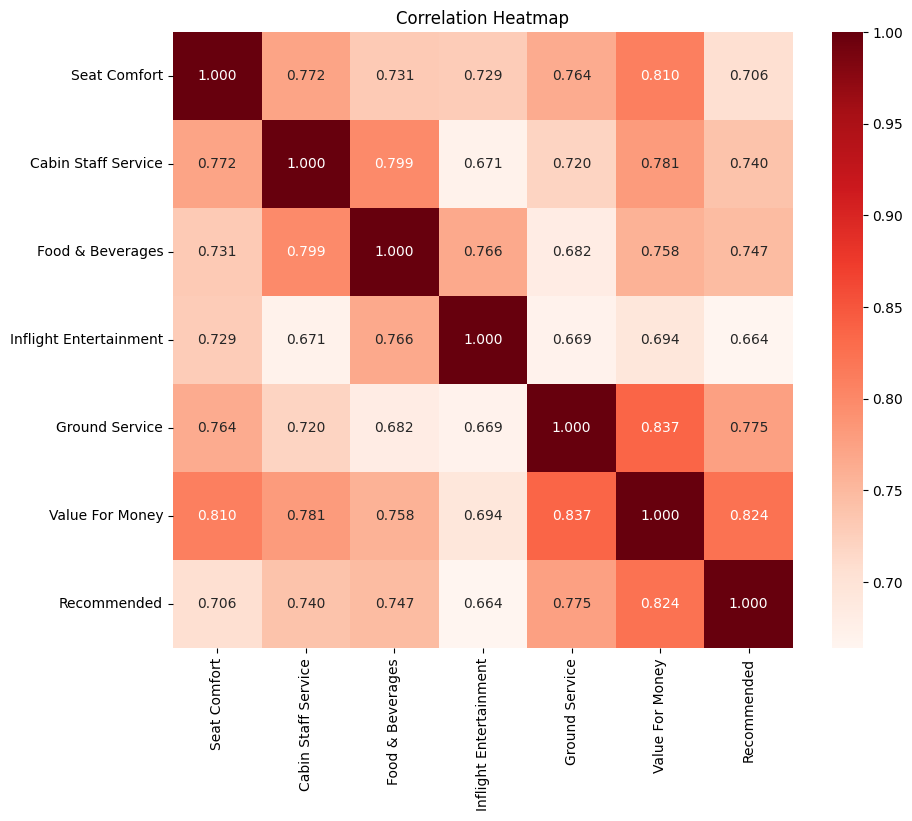

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_corr[rating_cols + ['Recommended']].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix,
            annot=True,        # shows values
            fmt=".3f",
           cmap = 'Reds')         

plt.title("Correlation Heatmap")
plt.show()

- Value for money shows the strongest positive correlation with recommendation (r = 0.82), indicating a strong linear association between perceived value and the likelihood of recommending the airline.
  
- Ground service (r = 0.77) and cabin staff service (r = 0.74) also exhibit strong positive correlations, suggesting that improvements in these attributes are closely associated with higher recommendation levels.

- Food and beverages (r = 0.75) and seat comfort (r = 0.71) demonstrate strong positive relationships with recommendation, indicating consistent association across core service attributes.

- Inflight entertainment shows the lowest correlation (r = 0.66), reflecting a comparatively weaker, though still positive, linear relationship with recommendation behaviour.

- Overall, all service attributes display strong positive correlations (r > 0.65) with recommendation, indicating that higher service ratings are consistently associated with increased likelihood of customer recommendation.

# Regression Analysis: Impact of Service Attributes on Recommendation Behaviour

In [44]:
df_reg = df_corr.dropna()

In [45]:
X = df_reg[['Seat Comfort',
            'Cabin Staff Service',
            'Food & Beverages',
            'Inflight Entertainment',
            'Ground Service',
            'Value For Money']]

y = df_reg['Recommended']

In [46]:
X = sm.add_constant(X)

## Fit the Regression Model

In [47]:
model = sm.OLS(y, X).fit()

In [48]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Recommended   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     422.8
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          3.86e-254
Time:                        12:49:04   Log-Likelihood:                -29.245
No. Observations:                 879   AIC:                             72.49
Df Residuals:                     872   BIC:                             105.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0.3613      0.019    -18.894      0.000      -0.399      -0.324
Seat Comfort               0.0151      0.011      1.361      0.174      -0.007       0.037
Cabin Staff Service        0.0084      0.010      0.802      0.423      -0.012       0.029
Food & Beverages           0.0370      0.011      3.399      0.001       0.016       0.058
Inflight Entertainment     0.0155      0.009      1.650      0.099      -0.003       0.034
Ground Service             0.0703      0.009      7.710      0.000       0.052       0.088
Value For Money            0.1333      0.012     11.514      0.000       0.111       0.156
==============================================================================
Omnibus:                       61.085   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              191.858
Skew:                          -0.286   Prob(JB):                     2.18e-42
Kurtosis:                       5.216   Cond. No.                         18.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- The regression model demonstrates strong explanatory power (R² = 0.744), indicating that approximately 74.4% of the variation in customer recommendation behaviour is explained by the service quality attributes.

- The overall model is statistically significant (F = 422.8, p < 0.001), confirming that the independent variables collectively have a meaningful impact on recommendation behaviour.

- Value for Money (β = 0.133, p < 0.001) emerges as the most influential predictor, indicating that perceived value is the strongest driver of customer recommendation.

- Ground Service (β = 0.070, p < 0.001) and Food & Beverages (β = 0.037, p = 0.001) also show significant positive effects, suggesting that operational efficiency and onboard service quality contribute to recommendation decisions.

- Seat Comfort (p = 0.174) and Cabin Staff Service (p = 0.423) are not statistically significant, while Inflight Entertainment (p = 0.099) shows weak significance, indicating that these factors do not have a strong independent impact when other variables are considered.

- The results highlight that while multiple service attributes are associated with customer satisfaction, only a few key factors particularly value for money and ground service play a decisive role in influencing recommendation behaviour.